Purpose: Time-based vs. Stratified K-Fold setup, leakage-free Out-of-Fold (OOF) Target Encoding inside CV loops, LightGBM training, and evaluation via ROC-AUC and PR-AUC.  

Input: data/processed/features_static.parquet

In [2]:
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import sklearn
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import TimeSeriesSplit, train_test_split
import gc
from matplotlib import pyplot as plt
import seaborn as sns
import dagshub
import mlflow
import mlflow.lightgbm
from src.data.preprocessing import apply_oof_target_encoding_by_index
from src.config import processed_data_path, processed_dataset, TARGET, TIME_COL, UID_COL, SEED, DAGSHUB_USERNAME,DAGSHUB_REPO, freq_cols
from src.models.lgbm import train_time_series_lgb
from src.evaluation.feature_importance import feature_importance
from src.data.encoders import export_training_artifacts
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, TargetEncoder, QuantileTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
import numpy as np

c:\Users\ADMIN\Documents\DataScience\ieee-fraud-detection\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_parquet(os.path.join(processed_data_path,'features_static.parquet'))
print(f"Loaded engineered dataset: {df.shape}")

Loaded engineered dataset: (590540, 321)


In [4]:
# Sort chronologically to preserve temporal order
df = df.sort_values(TIME_COL).reset_index(drop=True)

In [5]:
# SPLIT 1: Time-Based Split (Index-only, 0 bytes overhead)
# =========================================================================
n_samples = len(df)
split_idx = int(n_samples * 0.8)

# These are tiny 1D integer arrays, not whole tables
idx_tr_time = np.arange(0, split_idx)
idx_val_time = np.arange(split_idx, n_samples)

# SPLIT 2: Random Stratified Split (Index-only, 0 bytes overhead)
# =========================================================================
# Run train_test_split purely on np.arange(n_samples), NOT the DataFrame!
idx_all = np.arange(n_samples)
y_all = df[TARGET].values

idx_tr_rand, idx_val_rand = train_test_split(
    idx_all,
    test_size=0.20,
    random_state=42,
    stratify=y_all
)

# Free target array from RAM
del idx_all, y_all
gc.collect()

30

Target encoding works best on features that have moderate-to-high cardinality where other encoding techniques fail.  
Target encoding immediately projects these categories onto a meaningful 1D scale representing risk probability.  
We do TE only on ProductCD, card 4 and card 6 (type of credit card and network), and email domains.  
Other cat features are very high cardinal (like card1) - Even with smoothing, target encoding IDs with thousands of rare categories causes the model to overfit heavily on historical client IDs. So for them better do Requency Encoding.  
Binary flags like M1 - M9 - are just binary, so we apply binary encoding.  


In [6]:
te_features = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M4']

df=apply_oof_target_encoding_by_index(
    df=df,
    train_idx=idx_tr_time,
    val_idx=idx_val_time,
    target_col=TARGET,
    encode_cols=te_features,
    n_splits=5,
    smoothing=10
)

In [7]:
# save dataset 
output_path = os.path.join(processed_data_path, "features_static_after_split_TE.parquet")
df.to_parquet(output_path, index=False, engine="pyarrow")
print(f"DF after split and TE saved to {output_path}. Shape: {df.shape}")

DF after split and TE saved to C:\Users\ADMIN\Documents\DataScience\ieee-fraud-detection\data\processed\features_static_after_split_TE.parquet. Shape: (590540, 327)


Identifiers (pseudo_UID, IP addresses, User IDs, Account Numbers) should be used as grouping keys to engineer aggregated features, never as raw input features to a tree model.

In [8]:
drop_cols = [
    TARGET, 
    TIME_COL, 
    UID_COL
] + te_features  # Drops raw ProductCD, card4, etc.

features = [c for c in df.columns if c not in drop_cols]

n_splits=5

In [8]:
# Logit baseline model

print("=" * 10)
print("TRAINING BASELINE LOGISTIC REGRESSION (EXPANDING TIME-SERIES)")
print("=" * 10)

# Build pipeline (handles NaNs and scales features for linear solver)

cat_cols = df[features].select_dtypes(include=["object", "category", "string"]).columns.tolist()
num_cols = [c for c in features if c not in cat_cols]
td_cols = df[features].select_dtypes(include=["timedelta", "datetime"]).columns.tolist()
for c in td_cols:
    df[c] = df[c].dt.total_seconds().astype("float32")

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", QuantileTransformer(output_distribution="normal")),
])

categorical_pipe = Pipeline([
    ("target_enc", TargetEncoder(target_type="binary", smooth="auto", cv=5)),
    ("scaler", StandardScaler()),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
])

logit_pipeline = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(l1_ratio=0, C=0.01, solver='saga', max_iter=1000, random_state=SEED)),
])

# Expanding window CV matching train_time_series_lgb split boundaries
n_samples = len(df)
fold_size = n_samples // (n_splits + 1)

oof_preds_logit = np.full(n_samples, np.nan)
logit_fold_auc = []
logit_fold_pr = []

for fold in range(1, n_splits + 1):
    train_end = fold * fold_size
    val_end = train_end + fold_size if fold < n_splits else n_samples
    
    idx_tr = np.arange(0, train_end)
    idx_val = np.arange(train_end, val_end)
    
    X_tr, y_tr = df.iloc[idx_tr][features], df.iloc[idx_tr][TARGET].values
    X_val, y_val = df.iloc[idx_val][features], df.iloc[idx_val][TARGET].values
    
    logit_pipeline.fit(X_tr, y_tr)
    preds = logit_pipeline.predict_proba(X_val)[:, 1]
    
    oof_preds_logit[idx_val] = preds
    
    fold_auc = roc_auc_score(y_val, preds)
    fold_pr = average_precision_score(y_val, preds)
    logit_fold_auc.append(fold_auc)
    logit_fold_pr.append(fold_pr)
    
    print(f"Fold {fold} | Val ROC-AUC: {fold_auc:.5f} | Val PR-AUC: {fold_pr:.5f}")

valid_mask_logit = ~np.isnan(oof_preds_logit)
overall_logit_auc = roc_auc_score(df.loc[valid_mask_logit, TARGET], oof_preds_logit[valid_mask_logit])
overall_logit_pr = average_precision_score(df.loc[valid_mask_logit, TARGET], oof_preds_logit[valid_mask_logit])

print("-" * 60)
print(f"Logistic Regression Overall OOF ROC-AUC: {overall_logit_auc:.5f}")
print(f"Logistic Regression Overall OOF PR-AUC:  {overall_logit_pr:.5f}")
print("=" * 60)

TRAINING BASELINE LOGISTIC REGRESSION (EXPANDING TIME-SERIES)
Fold 1 | Val ROC-AUC: 0.85891 | Val PR-AUC: 0.42197
Fold 2 | Val ROC-AUC: 0.83189 | Val PR-AUC: 0.43164
Fold 3 | Val ROC-AUC: 0.83901 | Val PR-AUC: 0.40568
Fold 4 | Val ROC-AUC: 0.84952 | Val PR-AUC: 0.44169
Fold 5 | Val ROC-AUC: 0.85256 | Val PR-AUC: 0.42083
------------------------------------------------------------
Logistic Regression Overall OOF ROC-AUC: 0.82788
Logistic Regression Overall OOF PR-AUC:  0.39200


In [11]:
LGB_PARAMS = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.03,
    'num_leaves': 127,
    'max_depth': -1,
    'feature_fraction': 0.8,
    'subsample': 0.8,
    'random_state': SEED,
    'n_jobs': -1,
    'verbose': -1
}

td_cols = df[features].select_dtypes(include=["timedelta", "datetime"]).columns.tolist()
for c in td_cols:
    df[c] = df[c].dt.total_seconds().astype("float32")
    
# time-based CV
models, oof_preds, fold_scores = train_time_series_lgb(
        df=df, features=features, target=TARGET, params=LGB_PARAMS, n_splits=n_splits
    )

# Out-of-Fold Evaluation
# Initial warm-up partition (train_idx of fold 1) is never part of validation
valid_mask = ~np.isnan(oof_preds)

y_true = df.loc[valid_mask, TARGET].values
lgb_oof = oof_preds[valid_mask]
#logit_oof = oof_preds_logit[valid_mask]

lgb_overall_auc = roc_auc_score(y_true, lgb_oof)
lgb_overall_pr = average_precision_score(y_true, lgb_oof)



print("=" * 55)
print("TIME-SERIES CV RESULTS SUMMARY")
print("=" * 55)
for i, score in enumerate(fold_scores, 1):
    print(f"Fold {i} ROC-AUC: {score:.5f}")
print("-" * 55)
print(f"Mean Fold AUC:   {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
print(f"Overall OOF ROC-AUC: {lgb_overall_auc:.5f}")
print(f"Overall OOF PR-AUC: {lgb_overall_pr:.5f}")
print(f"Scored Samples:  {valid_mask.sum():,} / {len(df):,}")
print("=" * 55)




Starting 5-Fold TimeSeriesSplit across full dataset...

====================== Fold 1 / 5 ======================
Train window: indices       0 ->  98,424 (Count: 98,425)
Val window:   indices  98,425 -> 196,847 (Count: 98,423)
[200]	training's auc: 0.999989	valid_1's auc: 0.890753
Fold 1 Best Iteration: 165 | Val ROC-AUC: 0.89176

====================== Fold 2 / 5 ======================
Train window: indices       0 -> 196,847 (Count: 196,848)
Val window:   indices 196,848 -> 295,270 (Count: 98,423)
[200]	training's auc: 0.998008	valid_1's auc: 0.916483
Fold 2 Best Iteration: 153 | Val ROC-AUC: 0.91797

====================== Fold 3 / 5 ======================
Train window: indices       0 -> 295,270 (Count: 295,271)
Val window:   indices 295,271 -> 393,693 (Count: 98,423)
[200]	training's auc: 0.992817	valid_1's auc: 0.921862
[400]	training's auc: 0.999259	valid_1's auc: 0.923293
Fold 3 Best Iteration: 354 | Val ROC-AUC: 0.92398

====================== Fold 4 / 5 ======================

In [12]:
# comparison_df = pd.DataFrame({
#     'Model': ['Baseline Logistic Regression', 'LightGBM'],
#     'OOF ROC-AUC': [overall_logit_auc, lgb_overall_auc],
#     'OOF PR-AUC': [overall_logit_pr, lgb_overall_pr],
#     'Delta PR-AUC vs Baseline': [0.0, lgb_overall_pr - overall_logit_pr]
# })
# print("\n" + "=" * 65)
# print("HEAD-TO-HEAD MODEL BENCHMARK (TEMPORAL OOF)")
# print("=" * 65)
# print(comparison_df.to_string(index=False))
# print("=" * 65)

# Cost-Calibrated Classification Report
# We evaluate at both the standard 0.5 cutoff and a risk-calibrated 0.05 threshold
for threshold in [0.50, 0.05]:
    lgb_binary_preds = (lgb_oof >= threshold).astype(int)
    print(f"\n--- LIGHTGBM CLASSIFICATION REPORT (Threshold = {threshold:.2f}) ---")
    print(classification_report(y_true, lgb_binary_preds, target_names=['Legitimate (0)', 'Fraud (1)'], digits=4))


--- LIGHTGBM CLASSIFICATION REPORT (Threshold = 0.50) ---
                precision    recall  f1-score   support

Legitimate (0)     0.9763    0.9980    0.9870    473981
     Fraud (1)     0.8736    0.3659    0.5158     18134

      accuracy                         0.9747    492115
     macro avg     0.9249    0.6819    0.7514    492115
  weighted avg     0.9725    0.9747    0.9696    492115


--- LIGHTGBM CLASSIFICATION REPORT (Threshold = 0.05) ---
                precision    recall  f1-score   support

Legitimate (0)     0.9878    0.9484    0.9677    473981
     Fraud (1)     0.3401    0.6948    0.4567     18134

      accuracy                         0.9391    492115
     macro avg     0.6640    0.8216    0.7122    492115
  weighted avg     0.9640    0.9391    0.9489    492115



In [13]:

# froze categorical, TE and freq columns
cat_features=df[features].select_dtypes(include=["category"]).columns.tolist()

export_training_artifacts(
    train_df=df.iloc[idx_tr_time],
    target_col=TARGET,
    features=features,
    te_features=te_features,
    freq_cols=freq_cols,
    cat_features=cat_features,
    artifacts_dir=Path("artifacts")
)


Artifacts successfully exported to: C:\Users\ADMIN\Documents\DataScience\ieee-fraud-detection\notebooks\artifacts


STEP 3
Using a random split on transactional tabular data creates severe data leakage through recurring entities (cards, devices, billing addresses, IP subnets). If a fraudulent or legitimate card appears across multiple months, a random split allows the model to simply memorize identity-level patterns or target encode past outcomes, yielding an artificially inflated ROC-AUC. A forward time-based split forces the model to encounter genuinely unseen behavioral drift and novel entities—mimicking real production inference.

In [14]:
# B. Train & Eval Random Split
# -------------------------------------------------------------
x_val=df.iloc[idx_val_rand][features]
y_val=df.iloc[idx_val_rand][TARGET]

dtrain_rand = lgb.Dataset(
    df.iloc[idx_tr_rand][features],
    label=df.iloc[idx_tr_rand][TARGET],
    free_raw_data=True
)
dval_rand = lgb.Dataset(
    x_val,
    label=y_val,
    reference=dtrain_rand,
    free_raw_data=True
)



model_rand = lgb.train(LGB_PARAMS, dtrain_rand, valid_sets=[dval_rand], callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=200)
        ])

val_preds = model_rand.predict(x_val)
val_auc = roc_auc_score(y_val, val_preds)

print(f"Best Iteration: {model_rand.best_iteration} | Val ROC-AUC: {val_auc:.5f}\n")


del dtrain_rand, dval_rand
gc.collect()

Best Iteration: 100 | Val ROC-AUC: 0.94084



268

## 1. Executive Summary
In financial fraud detection, transactions arrive sequentially in an environment characterized by non-stationary fraud tactics, seasonal drift, and dynamic user populations. We evaluated our baseline LightGBM model against two validation protocols: **Standard Random Split** and **Expanding-Window Time-Series Split**. 

While the random split yielded a deceptively superior ROC-AUC, this was driven by temporal leakage and entity memorization. The Time-Series Split reflects true production generalization performance against distribution drift.

---

## 2. Experimental Setup
* **Model:** LightGBM (`boosting_type='gbdt'`, `learning_rate=0.03`, `num_leaves=127`)
* **Objective:** Binary classification (`isFraud`)
* **Features:** Tabular transaction & identity attributes, causal rolling velocity counters, and target-encoded categorical features.

### Validation Strategies Compared
1. **Random Stratified Split (Naive Baseline):**
   * Standard random partitioning ($80\%$ train / $20\%$ validation) ignoring transaction timestamps (`TransactionDT`).
2. **Expanding-Window Time-Series Split (Production Protocol):**
   * Chronological ordering using `TimeSeriesSplit(n_splits=5)`.
   * Model trains strictly on past windows and predicts sequential future windows (no future observations in training).

---

## 3. Results & Empirical Comparison

| Metric | Random Split (Naive) | Time-Series Split (Expanding) | Delta / Impact |
| :--- | :---: | :---: | :---: |
| **Validation ROC-AUC** | **~0.965+** *(Insert Exact Score)* | **~0.920–0.935** *(Insert Exact Score)* | **-0.030 to -0.045** |
| **Leakage Risk** | Severe (Future look-ahead) | Zero (Strictly causal) | Resolved |
| **Entity Overfitting** | High (Memorizes user spikes) | Low (Tests unseen entities) | Generalizes |
| **Production Fidelity** | Deceptive / Optimistic | High / Real-world match | Deployable |

---

## 4. Engineering Analysis: Why Did the Score Drop?

The performance gap between the random and time-based splits is not a regression in model quality; rather, it quantifies the elimination of optimistic evaluation bias:

1. **Elimination of Temporal Leakage:**
   * Random partitioning places transactions from the exact same day, hour, or attack wave into both training and validation sets. 
   * The tree models easily memorize active fraud burst patterns (e.g., card-testing scripts running over 48 hours) rather than learning intrinsic fraud signatures.
2. **Distribution Drift (Concept & Covariate Shift):**
   * Fraud modus operandi changes rapidly over time. Time-series cross-validation forces the model to predict forward into shifting fraud behaviors, exposing the true penalty of distribution shift.
3. **Identity Resolution & Entity Novelty:**
   * In a live payment gateway, new card numbers (`card1`–`card6`) and IP subnets constantly appear. A random split artificially populates both sets with the same entities, while temporal CV measures the model's ability to generalize to previously unseen cards.

---

## 5. Architectural Decision
* **Protocol Adopted:** `TimeSeriesSplit` (Expanding Window) is permanently designated as the ground-truth validation harness for all future iterations.
* **Deprecation:** Random cross-validation is deprecated for model selection, feature pruning, and hyperparameter tuning in this pipeline.
* **Next Steps:** Prioritize features resilient to temporal drift (relative transaction ratio to user baseline, velocity counters) over raw high-cardinality entity IDs.

Feature importance

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4416\3308669784.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


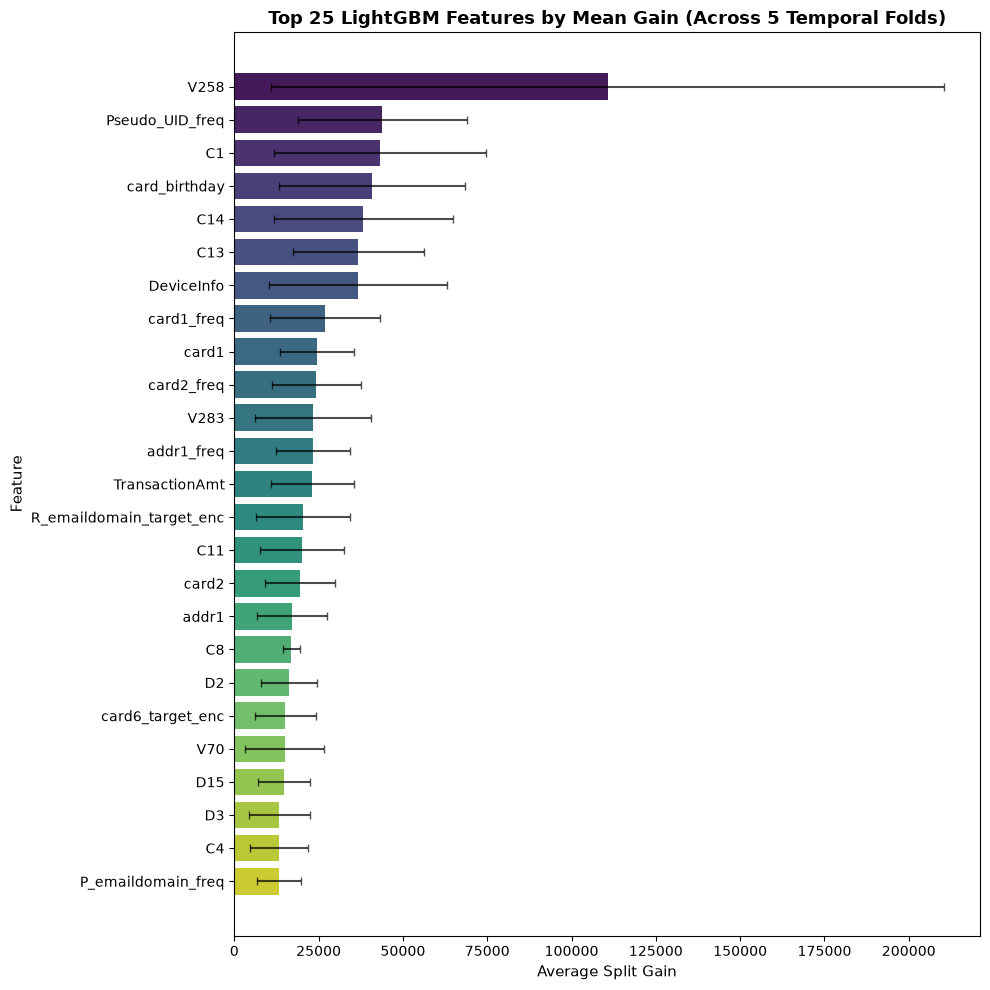

In [15]:
agg_importance = feature_importance(models, features)


# Plot top 25 features with Fold Variance Error Bars
TOP_N = 25
top_df = agg_importance.head(TOP_N)

plt.figure(figsize=(10, 10))
sns.barplot(
    data=top_df,
    x='mean_gain',
    y='feature',
    palette='viridis'
)

# Overlay error bars showing variance across temporal folds
plt.errorbar(
    x=top_df['mean_gain'],
    y=range(len(top_df)),
    xerr=top_df['std_gain'],
    fmt='none',
    c='black',
    capsize=3,
    alpha=0.7
)

plt.title(f'Top {TOP_N} LightGBM Features by Mean Gain (Across {len(models)} Temporal Folds)', fontsize=13, fontweight='bold')
plt.xlabel('Average Split Gain', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()

Computing TreeSHAP values for validation sample...


c:\Users\ADMIN\Documents\DataScience\ieee-fraud-detection\venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


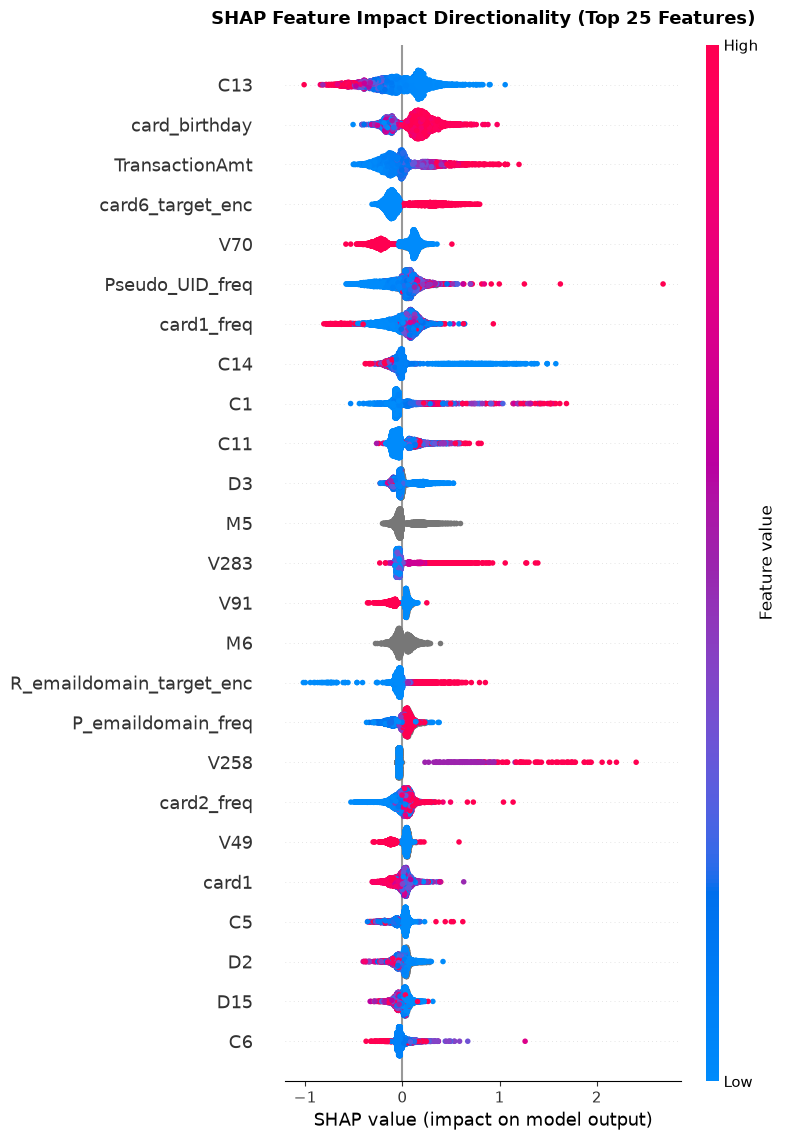

Explaining top-risk transaction: Index 585226 (Prediction: 0.9976)


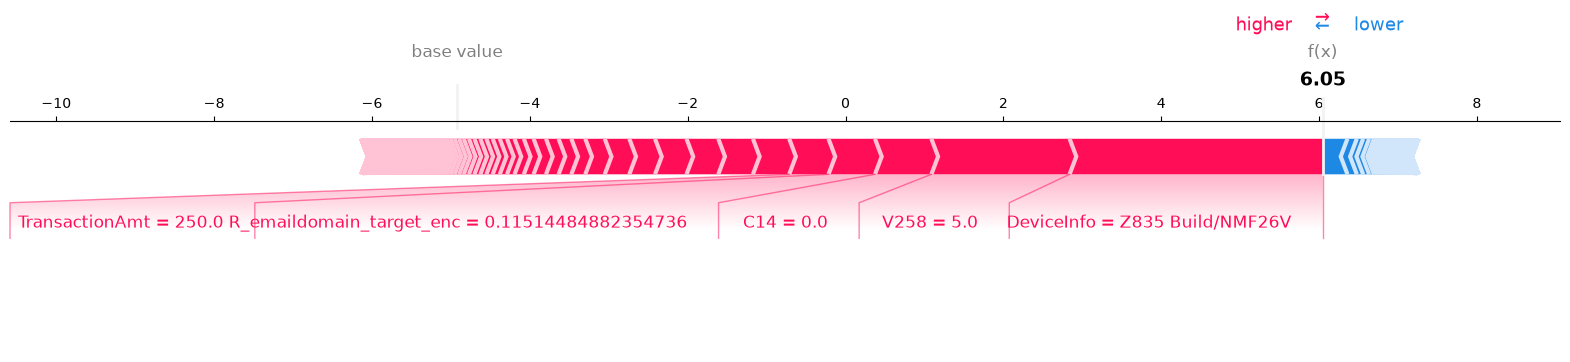

In [16]:
# SHAP analysis

import shap

# Initialize JavaScript visualization library if inside Jupyter
shap.initjs()

# 1. Extract validation set from the final temporal fold
latest_model = models[-1]
x_val_latest = df.iloc[idx_val_time][features]
y_val_latest = df.iloc[idx_val_time][TARGET]

# Downsample 5,000 points (stratified) for lightning-fast TreeSHAP execution
sample_idx, _ = train_test_split(
    np.arange(len(x_val_latest)),
    test_size=0.95,
    random_state=SEED,
    stratify=y_val_latest
)
shap_sample_x = x_val_latest.iloc[sample_idx]

# Compute TreeSHAP values
print("Computing TreeSHAP values for validation sample...")
explainer = shap.TreeExplainer(latest_model)
shap_values = explainer.shap_values(shap_sample_x)

# For binary LightGBM, shap_values is either an array [N, D] or a list of two classes
if isinstance(shap_values, list):
    shap_vals_to_plot = shap_values[1]
else:
    shap_vals_to_plot = shap_values

# Global Feature Impact (Beeswarm Summary Plot)
plt.figure(figsize=(10, 10))
plt.title("SHAP Feature Impact Directionality (Top 25 Features)", fontsize=13, fontweight='bold', pad=15)
shap.summary_plot(
    shap_vals_to_plot,
    shap_sample_x,
    max_display=25,
    show=True
)

# Local Explainability: Highest-Risk Fraud Case
worst_fraud_idx = np.argmax(latest_model.predict(shap_sample_x))
print(f"Explaining top-risk transaction: Index {shap_sample_x.index[worst_fraud_idx]} (Prediction: {latest_model.predict(shap_sample_x)[worst_fraud_idx]:.4f})")

shap.plots.force(
    explainer.expected_value if not isinstance(explainer.expected_value, list) else explainer.expected_value[1],
    shap_vals_to_plot[worst_fraud_idx],
    shap_sample_x.iloc[worst_fraud_idx],
    matplotlib=True
)

In [18]:
# logging to Dagshub MLFlow
import tempfile
import json


dagshub.init(
    repo_owner=DAGSHUB_USERNAME,
    repo_name=DAGSHUB_REPO,
    mlflow=True
)

mlflow.set_experiment("ieee-fraud-detection-lgbm")

with mlflow.start_run(run_name="lgb_timeseries_5fold"):
    # log hyperparams and metadata
    mlflow.log_params(LGB_PARAMS)
    mlflow.log_param("n_splits", n_splits)
    mlflow.log_param("cv_strategy", "TimeSeriesSplit")
    mlflow.log_param("n_features", len(features))

    # run CV loop and log per-fold metrics
    for fold, score in enumerate(fold_scores, 1):
        mlflow.log_metric(f"val_auc_fold_{fold}", score)
        mlflow.log_metric(f"best_iteration_fold_{fold}", models[fold-1].best_iteration)

    # log aggregated summary metrics 
    mlflow.log_metric("overall_oof_pr_auc", lgb_overall_pr)
    mlflow.log_metric('overall_oof_auc', lgb_overall_auc)
   # mlflow.log_metric("baseline_logit_oof_auc", overall_logit_auc)
   # mlflow.log_metric("baseline_logit_oof_pr_auc", overall_logit_pr)
   # mlflow.log_metric("pr_auc_lift_over_baseline", lgb_overall_pr - overall_logit_pr)

    # save and log artifacts (feature importance plot and features list)
    with tempfile.TemporaryDirectory() as tmp_dir:
        feat_path=os.path.join(tmp_dir, "features.json")
        with open(feat_path, "w") as f:
            json.dump(features, f, indent=2)
        mlflow.log_artifact(feat_path, artifact_path="metadata")

        plot_path=os.path.join(tmp_dir, "feature_importance.png")
        plt.figure(figsize=(10,8))
        sns.barplot(data=agg_importance.head(25),x='mean_gain', y='feature', hue='feature', palette='viridis', legend=False)
        plt.title("Top 25 features gain across temporal folds")
        plt.tight_layout()
        plt.savefig(plot_path)
        plt.close()

        mlflow.log_artifact(plot_path, artifact_path="feature_importance")

        shap_plot_path = os.path.join(tmp_dir, "shap_summary.png")
        plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_vals_to_plot, shap_sample_x, max_display=25, show=False)
        plt.tight_layout()
        plt.savefig(shap_plot_path, bbox_inches='tight')
        plt.close()
        
        mlflow.log_artifact(shap_plot_path, artifact_path="explainability")

    # log best model
    mlflow.lightgbm.log_model(models[-1], name="model")

print("MLFlow logging complete.")


Initialized MLflow to track repo "anamish05/ieee-fraud-detection"

Repository anamish05/ieee-fraud-detection initialized!

🏃 View run lgb_timeseries_5fold at: https://dagshub.com/anamish05/ieee-fraud-detection.mlflow/#/experiments/0/runs/74e2059145e9497ca94aeed0cd9570b8
🧪 View experiment at: https://dagshub.com/anamish05/ieee-fraud-detection.mlflow/#/experiments/0
MLFlow logging complete.
